# Exploratory Data Analysis

In [27]:
#import pandas

#hormones_selfreport = pandas.read_csv('hormones_and_selfreport.csv')
#hormones_selfreport.head()

In [64]:
#Importing essential libraries
from openpyxl import load_workbook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

#Libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


## Loading PCOS Dataset 

In [29]:
#Loading the excel file
pcos_wb = load_workbook("PCOS Dataset.xlsx")

#Selecting the active sheet 
pcos_ws = pcos_wb.active

#Taking all rows as a list of list/tuples 
pcos_data = list(pcos_ws.iter_rows(values_only=True))

#Seperating the header from the actual data rows
headers = pcos_data[0]
data_rows = pcos_data[1:]

#Creating a pandas dataframe
pcos_df = pd.DataFrame(data_rows, columns=headers)

#Priting the table
print(pcos_df.to_string())

#Reading data from the cells
#for row in pcos_ws.iter_rows(values_only=True):
#    print(row)

     Age  Height_cm  Weight_kg    BMI  Waist_Circumference_cm  Hip_Circumference_cm  Waist_Hip_Ratio  Age_at_Menarche  Menstrual_Cycle_Length_days  Menstrual_Irregularity  Gravidity  Parity  Hirsutism_Score_FG  Acne_Severity  Alopecia  Skin_Darkening_Acanthosis  Blood_Pressure_Systolic  Blood_Pressure_Diastolic  Physical_Activity_Level  Smoking_Status  Alcohol_Intake  Dietary_Sugar_Intake  Sleep_Hours  FSH_mIU_mL  LH_mIU_mL  LH_FSH_Ratio  Total_Testosterone_ng_dL  Free_Testosterone_pg_mL  DHEAS_ug_dL  Prolactin_ng_mL  Estradiol_pg_mL  Progesterone_ng_mL  SHBG_nmol_L  Fasting_Glucose_mg_dL  Fasting_Insulin_uIU_mL  HOMA_IR  HbA1c_percent  Total_Cholesterol_mg_dL  HDL_mg_dL  LDL_mg_dL  Triglycerides_mg_dL  Ovary_Volume_Left_cm3  Ovary_Volume_Right_cm3  Follicle_Count_Left  Follicle_Count_Right  CRP_mg_L  ALT_U_L  AST_U_L  TSH_uIU_mL  Vitamin_D_ng_mL  Hemoglobin_g_dL  PCOS_Diagnosis
0     39      152.1       63.4  25.82                    93.1                  91.5             0.86        

## Viewing List of Feature Names

In [30]:
#Viewing all feature names

#Loading the excel file
df = pd.read_excel("PCOS Dataset.xlsx")

#Extracting the column names
feature_names = df.columns.tolist()

#Printing the feature names
print(f"Total features: {len(feature_names)}\n")
for feature in feature_names:
    print(f"'{feature}',")
    

Total features: 52

'Age',
'Height_cm',
'Weight_kg',
'BMI',
'Waist_Circumference_cm',
'Hip_Circumference_cm',
'Waist_Hip_Ratio',
'Age_at_Menarche',
'Menstrual_Cycle_Length_days',
'Menstrual_Irregularity',
'Gravidity',
'Parity',
'Hirsutism_Score_FG',
'Acne_Severity',
'Alopecia',
'Skin_Darkening_Acanthosis',
'Blood_Pressure_Systolic',
'Blood_Pressure_Diastolic',
'Physical_Activity_Level',
'Smoking_Status',
'Alcohol_Intake',
'Dietary_Sugar_Intake',
'Sleep_Hours',
'FSH_mIU_mL',
'LH_mIU_mL',
'LH_FSH_Ratio',
'Total_Testosterone_ng_dL',
'Free_Testosterone_pg_mL',
'DHEAS_ug_dL',
'Prolactin_ng_mL',
'Estradiol_pg_mL',
'Progesterone_ng_mL',
'SHBG_nmol_L',
'Fasting_Glucose_mg_dL',
'Fasting_Insulin_uIU_mL',
'HOMA_IR',
'HbA1c_percent',
'Total_Cholesterol_mg_dL',
'HDL_mg_dL',
'LDL_mg_dL',
'Triglycerides_mg_dL',
'Ovary_Volume_Left_cm3',
'Ovary_Volume_Right_cm3',
'Follicle_Count_Left',
'Follicle_Count_Right',
'CRP_mg_L',
'ALT_U_L',
'AST_U_L',
'TSH_uIU_mL',
'Vitamin_D_ng_mL',
'Hemoglobin_g_dL',
'PCOS_Di

### Median Imputation of Negative Values within Features: Fasting_Insulin_uIU_mL, HOMA_IR, LH_mIU_mL, Free_Testosterone_pg_mL, Triglycerides_mg_dL

In [31]:
#Median Imputation
#First change negative values to NaN 

cols = [
    'Fasting_Insulin_uIU_mL',
    'HOMA_IR',
    'LH_mIU_mL',
    'Free_Testosterone_pg_mL',
    'Triglycerides_mg_dL',
]

#Converting negative values to nan
df[cols] = df[cols].mask(df[cols] < 0, np.nan)

#Checking to see if negative values were removed
print("Remaining negative values: ")
print((df[cols] < 0).sum())

Remaining negative values: 
Fasting_Insulin_uIU_mL     0
HOMA_IR                    0
LH_mIU_mL                  0
Free_Testosterone_pg_mL    0
Triglycerides_mg_dL        0
dtype: int64


In [32]:
#Converting NaN values to median values
for col in ['Fasting_Insulin_uIU_mL', 'HOMA_IR', 'LH_mIU_mL', 'Free_Testosterone_pg_mL', 'Triglycerides_mg_dL',]:
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)

#Checking that the dataset still contains 468 rows
print(f"Data shape: {df.shape}")

Data shape: (468, 52)


### Executing Feature Calculations for Mathematic Consistency

In [33]:
#BMI Calculation
df['BMI'] = df['Weight_kg'] / ( df['Height_cm'] / 100 ) ** 2

#Recalculating LH to FSH Ratio column and HOMA IR column
#For mathematical integrity

#LH/FSH Ratio Formula
df['LH_FSH_Ratio'] = df['LH_mIU_mL'] / df['FSH_mIU_mL']

#HOMA IR Formula
df['HOMA_IR'] = (df['Fasting_Insulin_uIU_mL'] * df['Fasting_Glucose_mg_dL']) / 405

In [34]:
#Replacing zero values with NaN
for col in ['Fasting_Insulin_uIU_mL', 'Triglycerides_mg_dL']:
    df[col] = df[col].replace(0.0, np.nan)
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)
    
#Recalculating HOMA IR again
#HOMA IR Formula
df['HOMA_IR'] = (df['Fasting_Insulin_uIU_mL'] * df['Fasting_Glucose_mg_dL']) / 405

#Checking to see if zero values were removed
print("Remaining zero values: ")
print((df[['Fasting_Insulin_uIU_mL', 'Triglycerides_mg_dL', 'HOMA_IR']] == 0).sum())


Remaining zero values: 
Fasting_Insulin_uIU_mL    0
Triglycerides_mg_dL       0
HOMA_IR                   0
dtype: int64


### Creating Histograms to assess the distributions of features

46


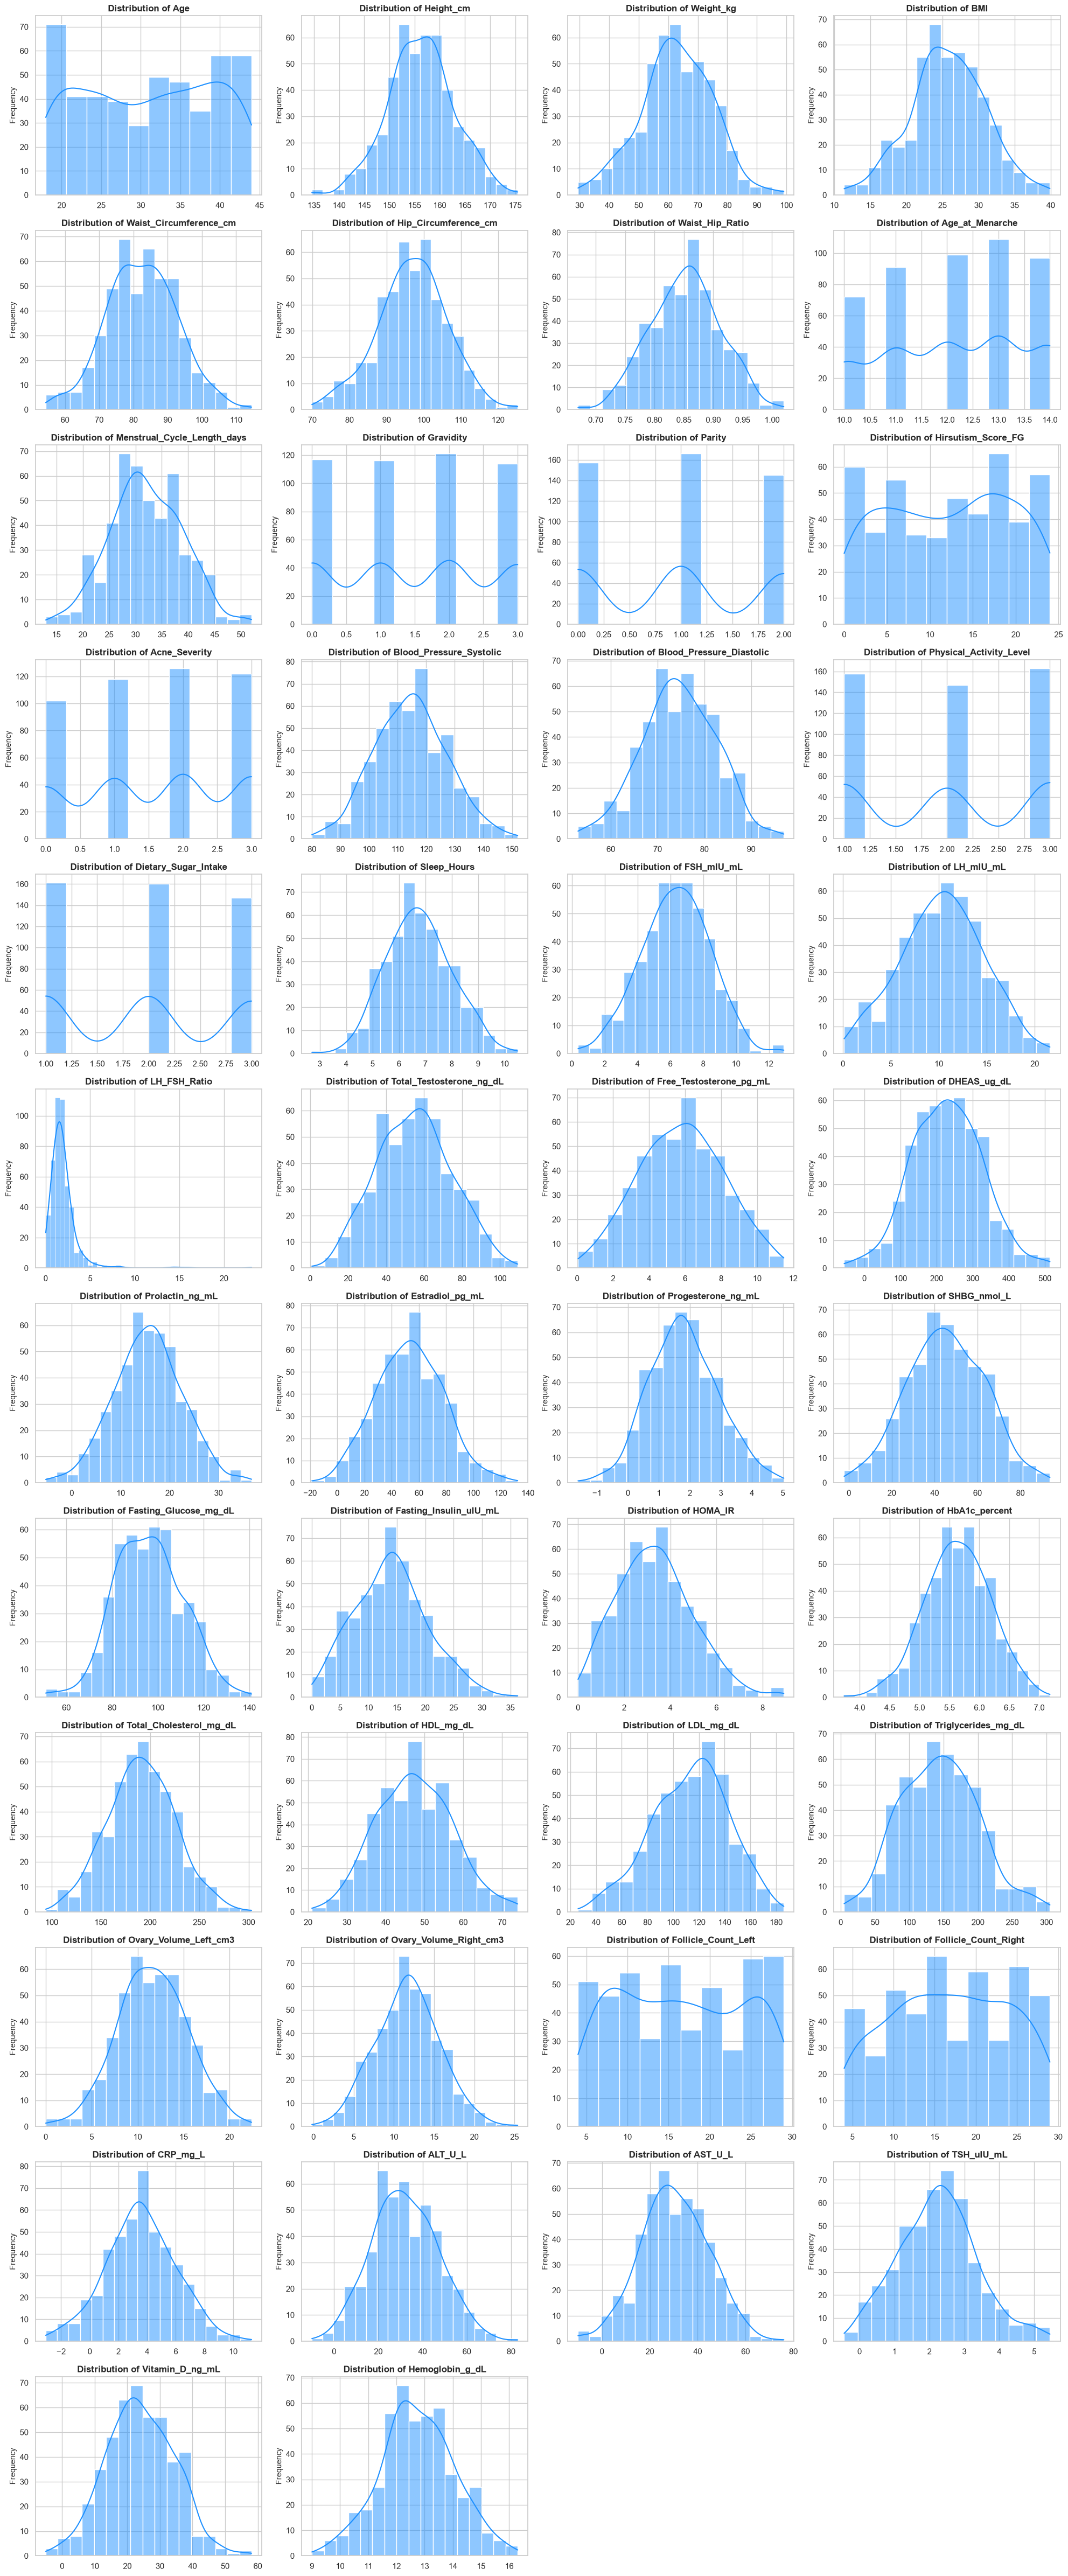

In [37]:
#Inline plotting
%matplotlib inline
sns.set_theme(style="whitegrid") #setting white grid style for box plots

#Only creating boxplots of continuous numeric features
cont_features = []
for col in df.select_dtypes(include=['number']).columns:
    if df[col].nunique() > 2: #excluding the binary features which only have 2 unique values
        cont_features.append(col)

num_features = len(cont_features)
print(num_features)

#Making 4 features display per row
features_per_row = 4
num_rows = (num_features + features_per_row - 1) // features_per_row
#Figure size configuration
fig, axes = plt.subplots(nrows=num_rows, ncols=features_per_row, figsize=(20, num_rows * 4))
axes = axes.flatten()

#Iteration through every continuous feature and creating the histogram
for i, col in enumerate(cont_features):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, color="dodgerblue", bins='auto')
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("") #Getting rid of redundant x axis label
    axes[i].set_ylabel("Frequency", fontsize=10)

    #Hiding blank subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Matrix 

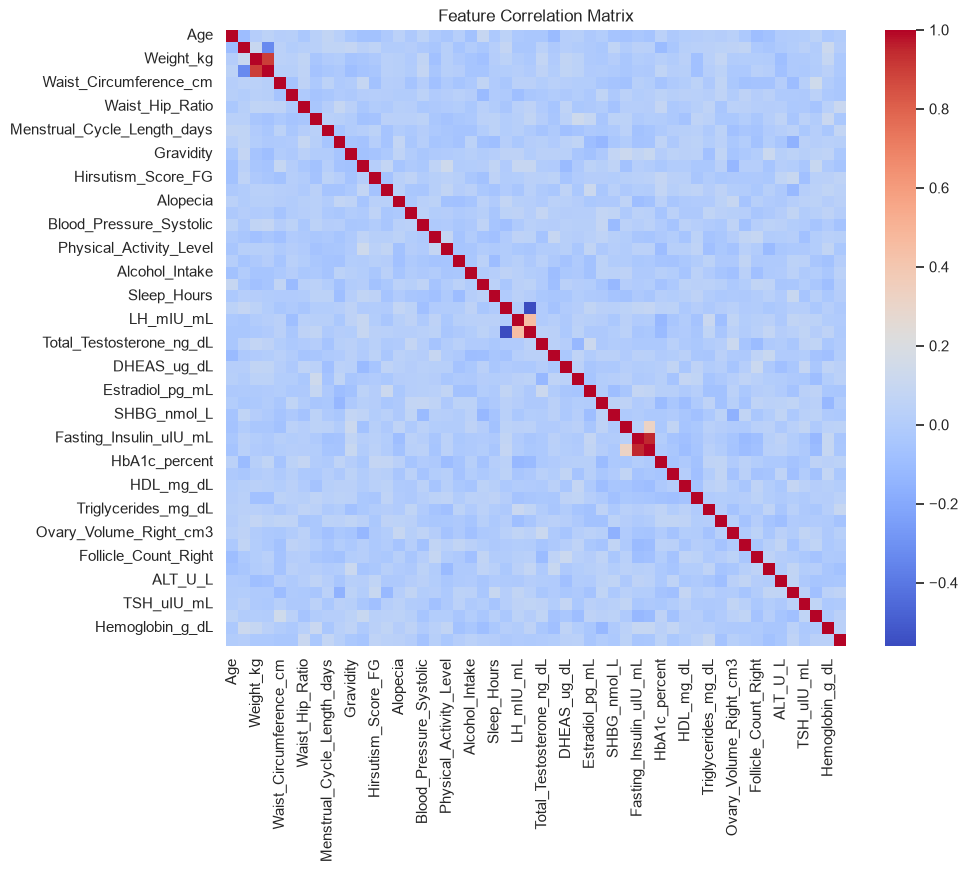

In [39]:
#Correlation matrix visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

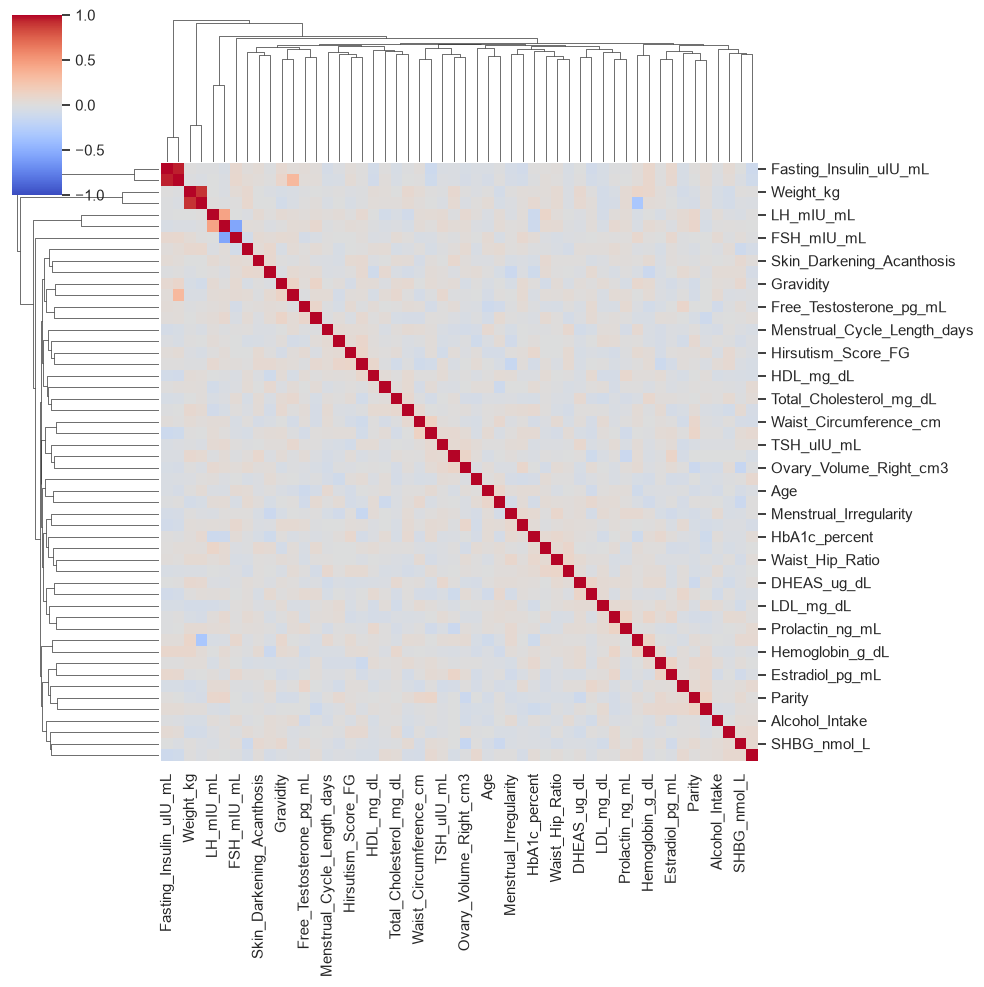

In [40]:
#Clustered heatmap
sns.clustermap(df.corr(), cmap='coolwarm', vmin=-1, vmax=1, annot=False)

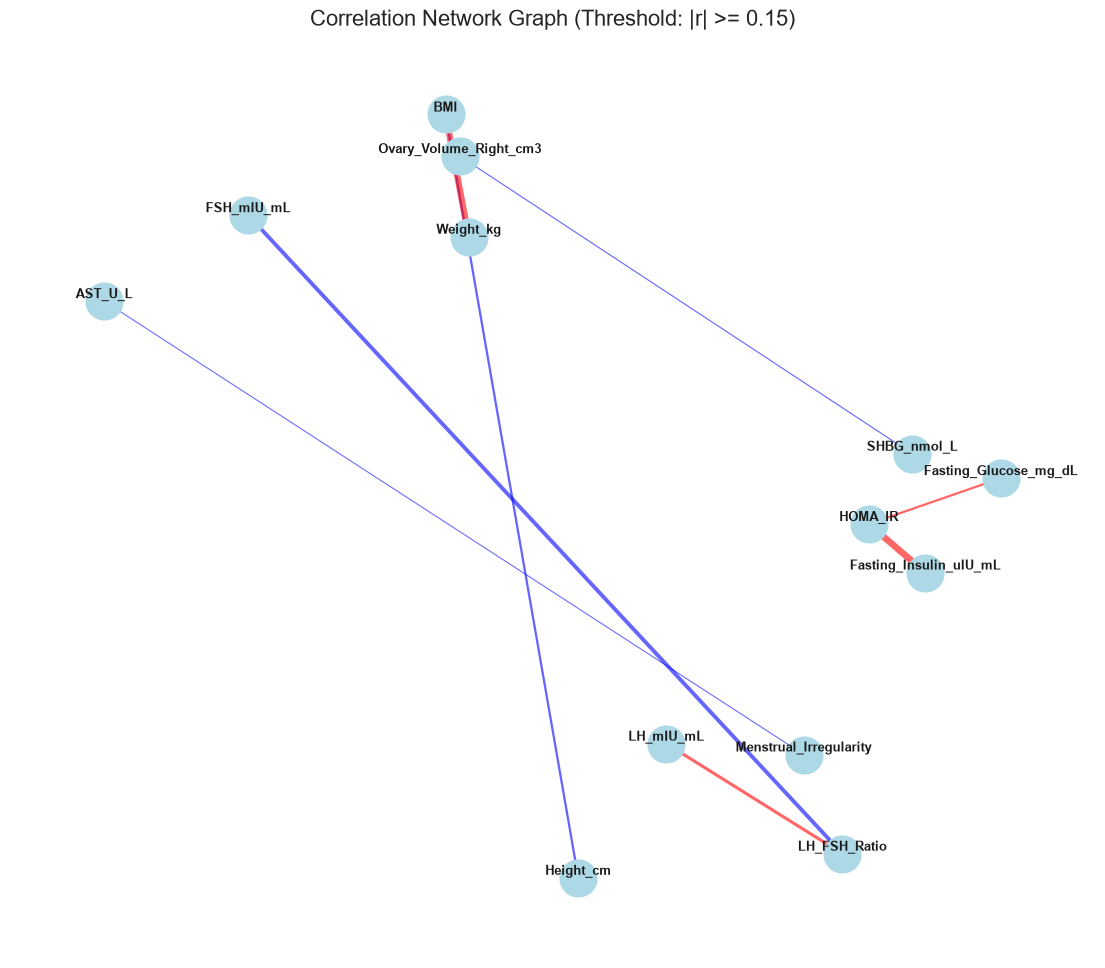

In [ ]:
#Thresholded Correlation Network Graph

#Creating the correlation map and creating an empty graph
corr = df.corr()
graph = nx.Graph()

#Setting a threshold
threshold = 0.15

#Adding edges based on if they are equal to or above the threshold 0.4
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            #Saving the edge with the correlation value
            graph.add_edge(corr.columns[i], corr.columns[j], weight=val)

#Removing isolated nodes with no strong correlations
isolated_nodes = [node for node, degree in dict(graph.degree()).items() if degree == 0]
graph.remove_nodes_from(isolated_nodes)

#Setting up layout 
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(graph, k=0.4, seed = 55)
edges= graph.edges(data=True) #retrieving weights for size and colour of edges
weights = [edge[2]['weight'] for edge in edges]
edge_colors = ['red' if w > 0 else 'blue' for w in weights]
edge_widths = [abs(w) * 5 for w in weights]

#Drawing components
nx.draw_networkx_nodes(graph, pos, node_color='lightblue', node_size = 700)
nx.draw_networkx_edges(graph, pos, edgelist=edges, edge_color = edge_colors, width=edge_widths, alpha = 0.6)
nx.draw_networkx_labels(graph, pos, font_size=9, font_weight='bold', verticalalignment = 'bottom')

plt.title(f"Correlation Network Graph (Threshold: |r| >= 0.15)", fontsize=16)
plt.axis('off')
plt.show()


#K-Means Clustering to Cluster PCOS Phenotypes for enhanced, hybrid recommender system


In [57]:
#Filtering the dataset to only apply K-means clustering to PCOS patients
pcos_only_df = df[df['PCOS_Diagnosis'] == 1].copy()

phenotype_features = [
    'HOMA_IR', 'BMI', 'Triglycerides_mg_dL',
    'Total_Testosterone_ng_dL', 'Menstrual_Cycle_Length_days',
    'Hirsutism_Score_FG', 'LH_FSH_Ratio'
]

#Applying the phenotypes to the dataset only for clustering
X_clustering = pcos_only_df[phenotype_features].copy()

#Fitting and transforming using a standard scaler 
scaler_cluster = StandardScaler()
X_clustering_scaled = scaler_cluster.fit_transform(X_clustering)

#Executing K-Means clustering
kmeans_model = KMeans(n_clusters=4, random_state = 82, n_init = 10)
pcos_only_df['Clinical_Cluster'] = kmeans_model.fit_predict(X_clustering_scaled)

#Printing the clustering results - clinical clusters
print(f"K-Means Clustering was executed on {len(pcos_only_df)} verified PCOS patients.")
print(pcos_only_df['Clinical_Cluster'].value_counts().rename(lambda x: f"PCOS Phenotype Cluster {x}"))

K-Means Clustering was executed on 208 verified PCOS patients.
Clinical_Cluster
PCOS Phenotype Cluster 0    69
PCOS Phenotype Cluster 2    48
PCOS Phenotype Cluster 3    47
PCOS Phenotype Cluster 1    44
Name: count, dtype: int64


### Evaluating the K-Means Clusters

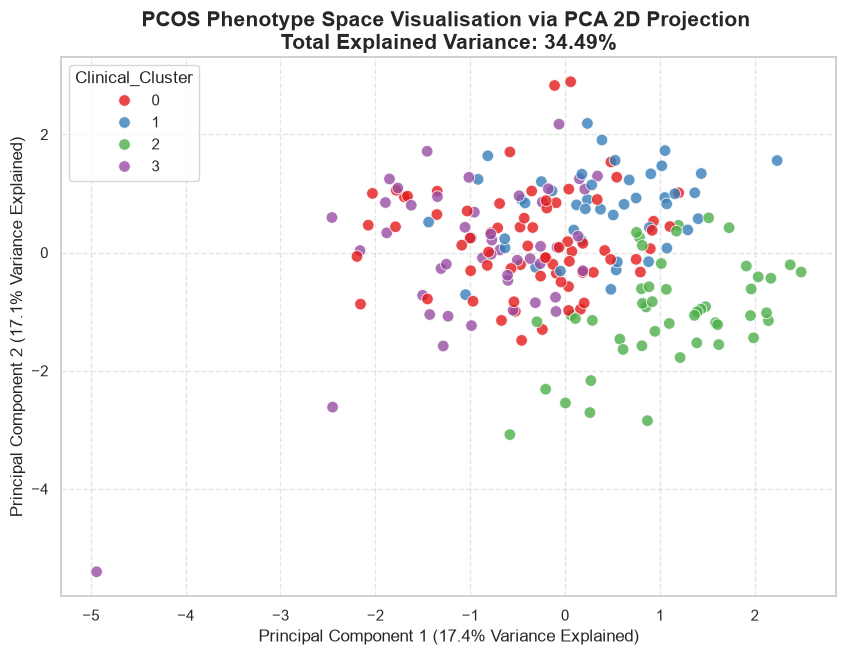

In [ ]:
#The K-Means Clustering is in a 7-Dimensional Coordinate Space due to 7 phenotype features
#Therefore to visualise the K-Means clusters, PCA is used to project the data to a 2D plane
#This is to assess the maximum possible geometric variance between patients

#Initialising PCA to reduce 7D scaled features down to 2 Principal Components
pca = PCA(n_components=2, random_state=50)
X_pca = pca.fit_transform(X_clustering_scaled)
#Attaching these coordinates back to the filtered dataframe
pcos_only_df['PCA_1'] = X_pca[:, 0]
pcos_only_df['PCA_2'] = X_pca[:, 1]

#Plotting the clusters onto a 2D Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA_1', y='PCA_2',
    hue='Clinical_Cluster',
    palette='Set1',
    data=pcos_only_df,
    alpha=0.8,
    edgecolor='w', s=70
)

#Calculating the variance explained by the axes
exp_var = pca.explained_variance_ratio_ * 100

plt.title(f'PCOS Phenotype Space Visualisation via PCA 2D Projection \nTotal Explained Variance: {exp_var[0]+exp_var[1]:.2f}%', fontsize=15, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({exp_var[0]:.1f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({exp_var[1]:.1f}% Variance Explained)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Raw Phenotypic Characteristics Matrix (Cluster Means):
-------------------------------------------------------------------------------------
                  HOMA_IR    BMI  Triglycerides_mg_dL  \
Clinical_Cluster                                        
0                    2.88  29.60               169.30   
1                    2.30  24.40               133.93   
2                    4.37  21.43               142.44   
3                    3.62  25.18               145.17   

                  Total_Testosterone_ng_dL  Menstrual_Cycle_Length_days  \
Clinical_Cluster                                                          
0                                    50.15                        30.36   
1                                    48.93                        35.77   
2                                    47.65                        36.94   
3                                    74.15                        28.64   

                  Hirsutism_Score_FG  LH_FSH_Ratio  
Clinical_Clu

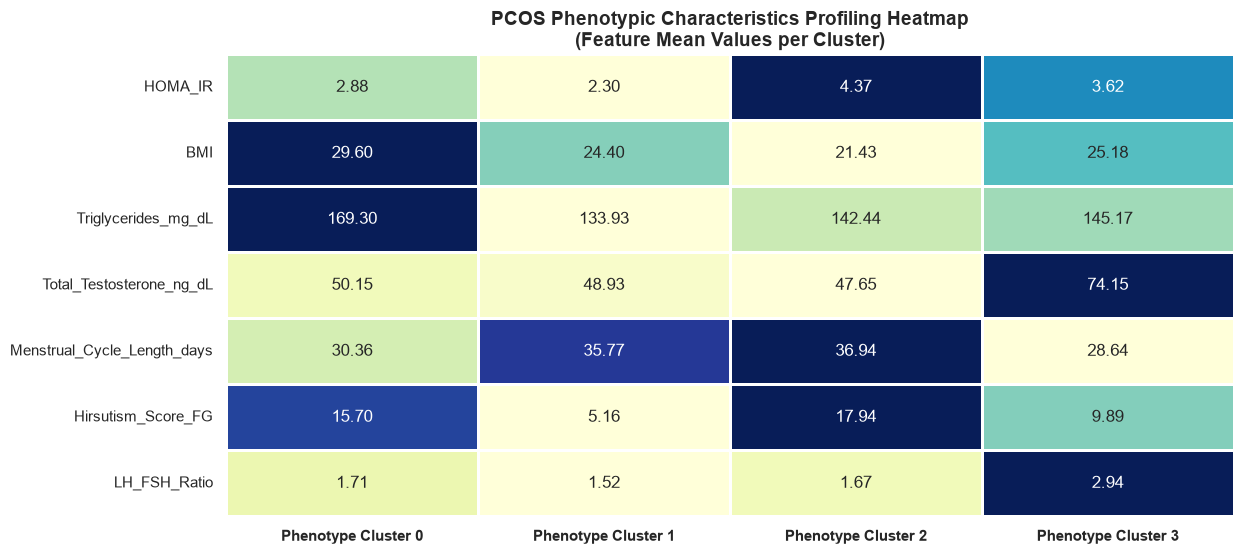

In [63]:
#Discovering characteristics of the phenotypes from K-means clustering
#To compare the clinical results of the K-means clusters to Clinical Standard Rotterdam phenotypes
#The mean feature values for each cluster is calculated 
cluster_profiles = pcos_only_df.groupby('Clinical_Cluster')[phenotype_features].mean()
print("Raw Phenotypic Characteristics Matrix (Cluster Means):")
print("-" * 85)
print(cluster_profiles.round(2))
print("-" * 85)

#Visualising the cluster phenotype characteristics as a normalised heatmap for clarity
#Scaling the columns locally so I can see which cluster scores 'highest' or 'lowest' for each trait
phenotype_scaler = MinMaxScaler()
cluster_phenotype_scaled = pd.DataFrame(
    phenotype_scaler.fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=[f"Phenotype Cluster {i}" for i in cluster_profiles.index]
)

#Plotting the heatmap
plt.figure(figsize=(13, 6))
sns.heatmap(cluster_phenotype_scaled.T, annot=cluster_profiles.T.values, fmt=".2f", cmap="YlGnBu", cbar=False, linewidths=1)
plt.title("PCOS Phenotypic Characteristics Profiling Heatmap\n(Feature Mean Values per Cluster)", fontsize=14, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11)
plt.show()

In [65]:
#Mathematical evaluation of the quality of the K-means Clusters using 3 metrics
sil_score = silhouette_score(X_clustering_scaled, pcos_only_df['Clinical_Cluster'])
db_score = davies_bouldin_score(X_clustering_scaled, pcos_only_df['Clinical_Cluster'])
ch_score = calinski_harabasz_score(X_clustering_scaled, pcos_only_df['Clinical_Cluster'])

print(f"Silhouette Coefficient: {sil_score:3f} (Target is to be close to +1.0)")
print(f"Davies-Bouldin Index: {db_score:.3f} (Target is to get a lower score to indicate cleaner cluster seperations)")
print(f"Calinski-Harabasz Index: {ch_score:.1f} (Target is a higher score to indicate tighter clusters)")

Silhouette Coefficient: 0.113810 (Target is to be close to +1.0)
Davies-Bouldin Index: 2.093 (Target is to get a lower score to indicate cleaner cluster seperations)
Calinski-Harabasz Index: 23.5 (Target is a higher score to indicate tighter clusters)


### Computing true centroid (mean profile) for each of the 4 Rotterdam clusters to generate expert PCOS profiles for more personalised recommendations for PCOS patients

In [ ]:
#Calculating the true centroid (mean profile) for each of the 4 Rotterdam Clusters
cluster_centroids = pcos_only_df.groupby('Clinical_Cluster')[phenotype_features].mean()

#Initialising a dictionary to store the 5D master target vecgtor for each cluster
#expert_profile_vectors = {}

#for cluster_id in cluster_centroids.index:
#    #Pulling the continuous average row for the PCOS community
#    centroid_record = cluster_centroids.loc[cluster_id]

    #Passing the centroid record into the nutrient vector rule engine 
#    expert_vector = nutrient_vector_scaled(centroid_record)
#    expert_profile_vectors[cluster_id] = expert_vector

#    print(f"Phenot")